# Homework 1: Thinking About Data

BEE 4850/5850

**Name**: Avinash Aravind

**ID**: aa2476

> **Due Date**
>
> Friday, 2/6/26, 9:00pm

### NOTE: The code in this notebook is NOT finalized, and some code is missing! For the full code used, see the hw01.qmd file instead.

### Instructions

The goal of this homework assignment is to introduce you to
simulation-based data analysis.

-   Problem 1 asks you to explore whether a difference between data
    collected from two groups might be statistically meaningful or the
    result of noise. This problem repeats the analysis from [Statistics
    Without The Agonizing
    Pain](https://www.youtube.com/watch?v=5Dnw46eC-0o) by John Rauser
    (which is a neat watch!).
-   Problem 2 asks you to load and conduct an exploratory analysis of an
    air quality and health dataset.
-   Problem 3 asks you to visualize and conduct an exploratory analysis
    of a cherry blossom dataset.
-   Problem 4 asks you to explore the impacts of selection biases on
    statistical relationships.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/Spring_2026/BEE4850/hw/hw01-avinasharavind`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [3]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSVFiles # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools

## Problems

### Problem 1 (7 points)

The underlying question we would like to address is: what is the
influence of drinking beer on the likelihood of being bitten by
mosquitoes? There is a mechanistic reason why this might occur:
mosquitoes are attracted by changes in body temperature and released
CO<sub>2</sub>, and it might be that drinking beer induces these
changes. We’ll analyze this question using (synthetic) data which
separates an experimental population into two groups, one which drank
beer and the other which drank only water.

First, we’ll load data for the number of bites reported by the
participants who drank beer. This is in a comma-delimited file,
`data/bites.csv` (which is grossly overkill for this assignment). Each
row contains two columns: the group (`beer` and `water`) the person
belonged to and the number of times that person was bitten.

In Julia, we can do this using
[`CSVFiles.jl`](https://github.com/queryverse/CSVFiles.jl), which will
read in the `.csv` file into a
[`DataFrame`](https://dataframes.juliadata.org/stable/), which is a
typical data structure for tabular data (and equivalent to a Pandas
`DataFrame` in Python or a `dataframe` in R).

In [3]:
data = DataFrame(load("data/bites.csv")) # load data into DataFrame

# print data variable (semi-colon suppresses echoed output in Julia, which in this case would duplicate the output)
@show data;

data = 43×2 DataFrame
 Row │ group   bites
     │ String  Int64
─────┼───────────────
   1 │ beer       27
   2 │ beer       20
   3 │ beer       21
   4 │ beer       26
   5 │ beer       27
   6 │ beer       31
   7 │ beer       24
   8 │ beer       21
   9 │ beer       20
  10 │ beer       19
  11 │ beer       23
  12 │ beer       24
  13 │ beer       28
  14 │ beer       19
  15 │ beer       24
  16 │ beer       29
  17 │ beer       18
  18 │ beer       20
  19 │ beer       17
  20 │ beer       31
  21 │ beer       20
  22 │ beer       25
  23 │ beer       28
  24 │ beer       21
  25 │ beer       27
  26 │ water      21
  27 │ water      22
  28 │ water      15
  29 │ water      12
  30 │ water      21
  31 │ water      16
  32 │ water      19
  33 │ water      15
  34 │ water      22
  35 │ water      24
  36 │ water      19
  37 │ water      23
  38 │ water      13
  39 │ water      22
  40 │ water      20
  41 │ water      24
  42 │ water      18
  43 │ water      20


How can we tell if there’s a meaningful difference between the two
groups? Naively, we might just look at the differences in group means.

> **Broadcasting**
>
> The subsetting operations in the below code use `.==`, which
> “broadcasts” the element-wise comparison operator == across every
> element. The decimal in front of `==` indicates that this should be
> used element-wise (every pair of elements compared for equality,
> returning a vector of `true` or `false` values); otherwise Julia would
> try to just check for vector equality (returning a single `true` or
> `false` value).
>
> Broadcasting is a very specific feature of Julia, so this syntax would
> look different in a different programming language.

In [4]:
# split data into vectors of bites for each group
beer = data[data.group .== "beer", :bites]
water = data[data.group .== "water", :bites]

observed_difference = mean(beer) - mean(water)
@show observed_difference;

observed_difference = 4.37777777777778


This tells us that, on average, the participants in the experiment who
drank beer were bitten approximately 4.4 more times than the
participants who drank water! Does that seem like a meaningful
difference, or could it be the result of random chance?

We will use a *simulation* approach to address this question, as
follows.

-   Suppose someone is skeptical of the idea that drinking beer could
    result in a higher attraction to mosquitoes, and therefore more
    bites. To this skeptic, the two datasets are really just different
    samples from the same underlying population of people getting bitten
    by mosquitoes, rather than two different populations with different
    propensities for being bitten. This is the skeptic’s *hypothesis*,
    versus our hypothesis that drinking beer changes body temperature
    and CO<sub>2</sub> release sufficiently to attract mosquitoes.
-   If the skeptic’s hypothesis is true, then we can “shuffle” all of
    the measurements between the two datasets and re-compute the
    differences in the means. After repeating this procedure a large
    number of times, we would obtain a distribution of the differences
    in means under the assumption that the skeptic’s hypothesis is true.
-   Comparing our experimentally-observed difference to this
    distribution, we can then evaluate the consistency of the skeptic’s
    hypothesis with the experimental results.

> **Why Do We Call This A Simulation-Based Approach?**
>
> This is a simulation-based approach because the “shuffling” is a
> non-parametric way of generating new samples from the underlying
> distribution (more on this later!).
>
> The alternative to this approach is to use a statistical test, such as
> a [t-test](https://en.wikipedia.org/wiki/Student%27s_t-test), which
> [may have other
> assumptions](https://en.wikipedia.org/wiki/Student%27s_t-test#Assumptions)
> which may not be appropriate for this setting, particularly given the
> seemingly small sample sizes.

#### Problem 1.1

Conduct the above procedure to generate 50,000 simulated datasets under
the skeptic’s hypothesis. Plot a histogram of the results and add a
dashed vertical line to show the experimental difference (if you are
using Julia, feel free to look at the [Making Plots with Julia
tutorial](https://viveks.me/simulation-data-analysis/tutorials/julia-plots.html)
on the class website).

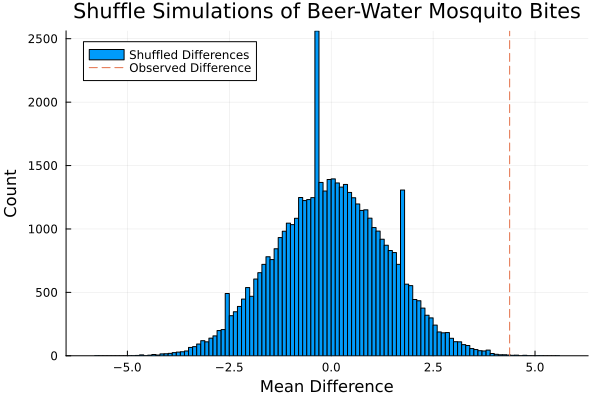

In [5]:
sim_diffs = []
for i in 1:50000
    biteshuffle = shuffle(data[!, :bites])
    datashuffle = DataFrame(group=data[!, :group], bites=biteshuffle)

    beer = datashuffle[datashuffle.group .== "beer", :bites]
    water = datashuffle[datashuffle.group .== "water", :bites]

    shuffle_difference = mean(beer) - mean(water)
    append!(sim_diffs, [shuffle_difference])
end

plot(sim_diffs, st=:histogram, label="Shuffled Differences", xlabel="Mean Difference", ylabel="Count", title="Shuffle Simulations of Beer-Water Mosquito Bites")
plot!([observed_difference], st=:vline , ls=:dash, label="Observed Difference")

<span style="color:gray">
<h6>Figure 1. Histogram of Mean Differences for 50000 shuffled "simulations" of mosquito bite data for beer vs. water drinkers.</h6>
</span>

#### Problem 1.2

Draw conclusions about the plausibility of the skeptic’s hypothesis that
there is no difference between groups. Feel free to use any quantitative
or qualitative assessments of your simulations and the observed
difference.

<span style="color:gray">

Based on the simulation results, the skeptic's hypothesis does not appear very plausible. As would be expected from a random shuffle, the difference between the randomized "beer" and "water" category means is centered around zero, with the majority of simulations having a mean difference between -2 and 2. However, the observed difference is well over 4, and there are only a very small number of shuffles with a mean difference that large. It is unlikely that such a large difference would be drawn from this distribution of random simulations, suggesting that there is a difference in mosquito bites for beer drinkers versus water drinkers.

</span>


### Problem 2 (5 points)

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))
contains data on the relationship between environmental conditions
(temperature and air quality) and deaths in Chicago from 1987–2000. The
dataset contains the following variables:

1.  The number of non-accidental deaths each day (`deaths`);
2.  The median density over the city of PM10 (large particulate matter)
    particles (`pm10median`);
3.  The median density over the city of PM 2.5 (small particulate
    matter) particles (`pm25median`);
4.  The median concentration of ozone (O\[3\]) (`o3median`);
5.  The median concentration of sulfur dioxide (SO\[2\]) (`so2median`);
6.  The time in days (`time`);
7.  The daily mean temperature (`tmpd`).

#### Problem 2.1

Load the dataset and compute the following summary statistics for each
column (you can do this using built-in functions as available in the
language you are using):

1.  Minimum, 25th percentile, median, 75th percentile, and maximum;
2.  Mean;
3.  Number of missing data entries (`NA`s).

What are the units for the temperatures? Explain why there are so many
negative values for the pollution variables.

In [ ]:
chicago = DataFrame(load("data/chicago.csv"))

describe(chicago, :min, :q25, :median, :q75,:max, :mean, :nmissing)
# OH MY GOD THIS IS SO MUCH EASIER IN JULIA THAN PANDAS

Row,variable,min,q25,median,q75,max,mean,nmissing
,Symbol,Real,Float64,Float64,Float64,Real,Float64,Int64
1,Column1,1,1279.25,2557.5,3835.75,5114,2557.5,0
2,death,69,105.0,114.0,124.0,411,115.419,0
3,pm10median,-37.3761,-13.1082,-3.53906,8.30292,320.725,-0.14639,251
4,pm25median,-16.4264,-6.58841,-1.32584,5.34377,38.1504,0.243053,4387
5,o3median,-24.7794,-10.2319,-3.32586,4.46821,43.6878,-2.17938,0
6,so2median,-8.2061,-2.68935,-1.21826,0.831593,28.9034,-0.636071,27
7,time,-2556.5,-1278.25,0.0,1278.25,2556.5,0.0,0
8,tmpd,-16.0,35.0,51.0,67.0,92.0,50.1933,0


#### Problem 2.2

Plot the number of deaths versus the time (convert the time to the
calendar date). Describe any patterns that you see.

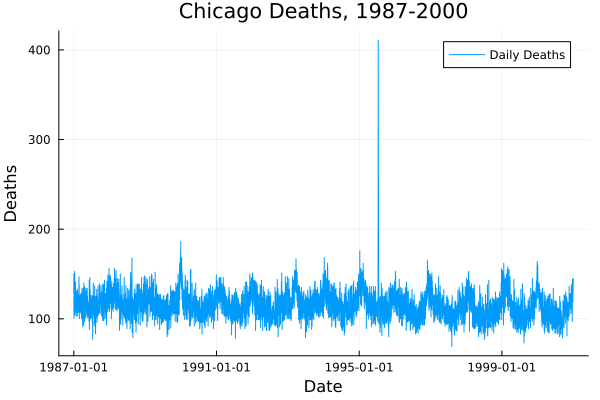

In [27]:
using Dates
ndays = length(chicago.time)
dates = []
for i = 0:ndays-1
    newdate = [Date("1987-01-01", dateformat"y-m-d")+Dates.Day(i)]
    append!(dates, newdate)
end

plot(dates, chicago.death, st=:line, label="Daily Deaths", xlabel="Date", ylabel="Deaths", title="Chicago Deaths, 1987-2000")

#### Problem 2.3

Plot the number of deaths versus the temperature. Describe any patterns
that you see.

#### Problem 2.4

What do you think has a clearer influence on the number of deaths: date
or temperature?

### Problem 3 (3 points)

Cherry trees flower in the spring, but the opening of their blossoms
requires warm temperatures and is delayed by cold. As a result, cherry
blossom flowering dates are a good proxy for springtime temperatures.
Due to the importance of cherry blossoms in Japanese culture, we have an
(incomplete) record of full blossom dates going back to around 800 CE,
which was developed by Prof. Yasuyuki Aono and several colleagues[1] and
used for temperature reconstructions.

This blossom date data is provided in `data/kyoto.csv`[2]. The three
columns are

1.  the year (CE),
2.  the numerical day of the year full flowering (*e.g.* Jan. 1 is day
    1, Dec. 31 is day 365 or 366);
3.  the date in the Gregorian calendar (*e.g.* Mar. 15 is 0315).

#### Problem 3.1

Load the data file and produce the following summary statistics for the
day (not the date) of full flowering (you can do this using built-in
functions as available in the language you are using):

1.  Minimum, 25th percentile, median, 75th percentile, and maximum;
2.  Mean;
3.  Number of missing data entries (`NA`s).

Why would it not make sense to calculate these summary statistics for
the date column?



In [4]:
blossoms = DataFrame(load("data/kyoto.csv"))

describe(blossoms, :min, :q25, :median, :q75,:max, :mean, :nmissing)

Row,variable,min,q25,median,q75,max,mean,nmissing
,Symbol,Int64,Float64,Float64,Float64,Int64,Float64,Int64
1,Year.AD,801,1104.5,1408.0,1711.5,2015,1408.0,0
2,Flowering.DOY,86,100.0,105.0,109.0,124,104.541,388
3,Flowering.MMDD,327,410.0,414.0,419.0,504,413.717,388


#### Problem 3.2

Plot the day of flowering against the year. Add horizontal lines showing
the mean date of flowering as well as the 25th and 75th percentiles. Do
you see any trends or patterns in the data?



### Problem 4 (5 points)

A scientific funding agency receives 200 proposals in response to a
call. The panel is asked to evaluate each proposal on two criteria:
scientific rigor and potential impact (or “newsworthiness”). After
standardizing each of these scores to independently follow a standard
normal distribution ($\text{Normal}(0, 1)$), the two standardized scores
are summed to get the total score for the proposal. Based on these total
scores, the top 10% of the proposals are selected for funding.

A researcher who is studying the relationship between rigor and impact
has used data on the funded proposals to claim high-impact proposals are
necessarily less rigorous, and indeed found a statistically significant
negative correlation between the rigor and impact scores for the funded
proposals. You are more skeptical and believe this effect is an artifact
from the selection process, which would make the claim a bit ironic.

#### Problem 4.1

Create a generative model for the grant-selection procedure under the
null assumption of no correlation between rigor and impact. You can
sample rigor and impact scores directly from $\text{Normal}(0, 1)$.
Generate 1,000 datasets using this model and flag the proposals which
would be funded in each. Plot a histogram of the correlations between
rigor and data for (a) the funded proposals and (b) the overall pool.
What do you observe?


#### Problem 4.2

Explain why, when conditioning on selection for funding, there might be
a negative correlation between rigor and impact even if there none
generally exists.

> **Selection-Distortion Effects**
>
> These **selection-distortion effects** are pretty common in
> observational data, going back to [work by Dawes in the 1970s on the
> lack of predictive ability of admission variables on student
> success](https://www.science.org/doi/abs/10.1126/science.187.4178.721)
> and including [studies claiming to identify a causal fingerprint of
> genes on
> outcomes](https://www.nature.com/articles/s41598-021-89020-x).
>
> This is, of course, just one example of how not thinking carefully
> about data-generating processes can fundamentally contaminate
> statistical analyses, emphasizing that **data do not have meaning
> absent a model for how they were generated**.

### Problem 5 (5 points)

You are trying to detect how prevalent cheating was on an exam. You are
skeptical of the efficacy of just asking the students if they cheated.
You are also concerned about privacy — your goal is not to punish
individual students, but to see if there are systemic problems that need
to be addressed. Someone proposes the following interview procedure,
which the class agrees to participate in:

> Each student flips a fair coin, with the results hidden from the
> interviewer. The student answers honestly if the coin comes up heads.
> Otherwise, if the coin comes up tails, the student flips the coin
> again, and answers “I did cheat” if heads, and “I did not cheat”, if
> tails.

You have a hypothesis that cheating was not prevalent, and the
proportion of cheaters was no more than 5% of the class; in other words,
we expect 5 “true” cheaters out of a class of 100 students. Our TA is
more jaded and thinks that cheating was more rampant, and that 30% of
the class cheated. The proposed interview procedure is noisy: the
interviewer does not know if an admission means that the student
cheated, or the result of a heads. However, it gives us a
data-generating process that we can model and analyze for consistency
with our hypothesis and that of the TA.

#### Problem 5.1

Derive and code a simulation model for the above interview procedure
given a “true” probability of cheating $p$. Simulate your model (for a
class of 100 students) 50,000 times under your hypothesis of 5%
cheating, the TA’s hypothesis of 30% cheating, and plot the resulting
datasets.

#### Problem 5.2

How many “Yes, I cheated” answers do you think you’d need to see to feel
confident concluding that the TA was right and why? You don’t need to do
a formal analysis, but can reason about this based on your plots.

## References

[1] Aono, Y., & Omoto, Y. (1993). Variation in the March mean
temperature deduced from cherry blossom in Kyoto since the 14th century.
Journal of Agricultural Meteorology, 48(5), 635–638.
<https://doi.org/10.2480/agrmet.48.635>

Aono, Y., & Omoto, Y. (1994). Estimation of temperature at Kyoto since
the 11th century. Using flowering data of cherry trees in old documents.
Journal of Agricultural Meteorology, 49(4), 263–272.
<https://doi.org/10.2480/agrmet.49.263>

Aono, Y., & Kazui, K. (2008). Phenological data series of cherry tree
flowering in Kyoto, Japan, and its application to reconstruction of
springtime temperatures since the 9th century. International Journal of
Climatology: A Journal of the Royal Meteorological Society, 28(7),
905–914. <https://doi.org/10.1002/joc.1594>

[2] The full data set from Prof. Aono has much more information, such as
the data sources and the type of historical evidence

In [ ]:
#| echo: false
all_cors = []
funded_cors = []

for i = 1:1000
    proposals = DataFrame(rigor=randn(200), impact=randn(200))
    proposals[!, :score] = proposals.rigor+proposals.impact
    q90 = percentile(proposals.score, 90)
    proposals[!, :accepted] = proposals.score .>= [q90]
    correlation_all = cor(Matrix(proposals[:,1:2]))[1,2]
    correlation_accepted = cor(Matrix(proposals[proposals.accepted .== true, 1:2]))[1,2]

    append!(all_cors, [correlation_all])
    append!(funded_cors, [correlation_accepted])
end

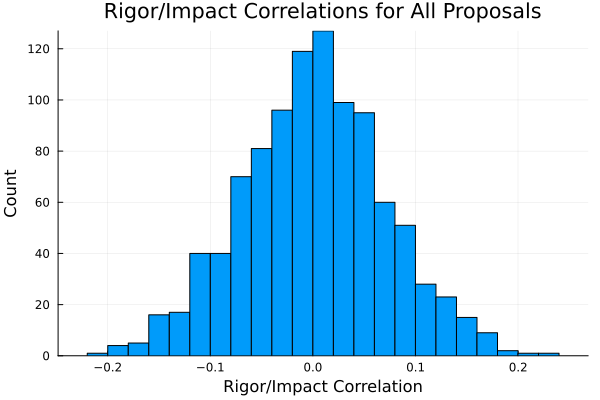

In [59]:
plot(all_cors, st=:histogram, legend=false, xlabel="Rigor/Impact Correlation", ylabel="Count", title="Rigor/Impact Correlations for All Proposals")

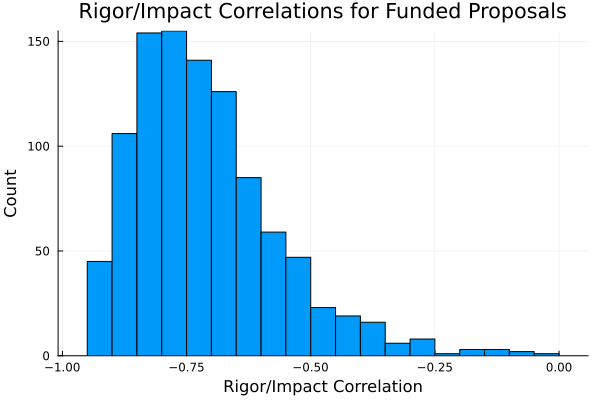

In [7]:
yes_counts_5 = []
for j = 1:50000
    ncheated = 0
    for i = 1:100
        cf1 = rand((1,2))
        if cf1 == 1 #Heads
            cheating = rand(1:20)
            if cheating == 20
                ncheated += 1
            end
        elseif cf1 == 2 #tails
            cf2 = rand((1,2))
            if cf2 == 1 #Heads
                ncheated += 1
            end
        end
    end
    append!(yes_counts_5, [ncheated])
end

yes_counts_30 = []
for j = 1:50000
    ncheated = 0
    for i = 1:100
        cf1 = rand((1,2))
        if cf1 == 1 #Heads
            cheating = rand(1:10)
            if cheating <= 3
                ncheated += 1
            end
        elseif cf1 == 2 #tails
            cf2 = rand((1,2))
            if cf2 == 1 #Heads
                ncheated += 1
            end
        end
    end
    append!(yes_counts_30, [ncheated])
end

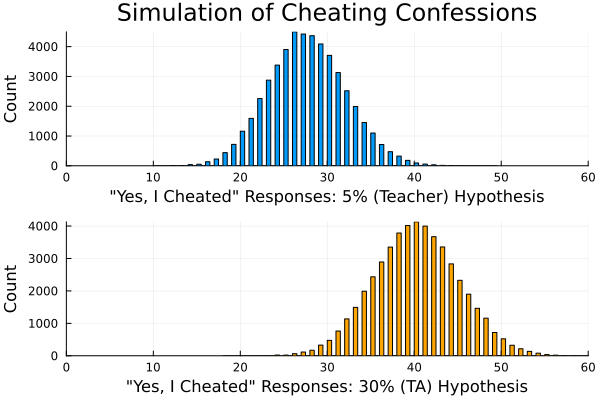

In [16]:
p1 = plot(yes_counts_5, st=:histogram, legend=false, xlabel=""""Yes, I Cheated" Responses: 5% (Teacher) Hypothesis""", ylabel="Count", xlim=(0,60))
p2 = plot(yes_counts_30, st=:histogram, legend=false, xlabel=""""Yes, I Cheated" Responses: 30% (TA) Hypothesis""", ylabel="Count", color="orange", xlim=(0,60))
plot(p1, p2, layout=(2,1), suptitle="Simulation of Cheating Confessions")